# Import thư viện

In [77]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_curve, classification_report, auc,
    confusion_matrix, brier_score_loss, log_loss, accuracy_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Tổng hợp dữ liệu thô đã thu thập vào 1 file

In [65]:
FEATURE_MAP = {
    'Date': 'Date',
    'Time': 'Time',
    'Total CPU Usage [%]':  'CPU_Load_Pct',
    'CPU Package [°C]': 'Temperature_C',
    'Other (Docking) [RPM]': 'Fan_RPM',
    'Core VIDs (avg) [V]': 'Voltage_V',
}
FILES = [
    ('Normal.CSV',   0),   # 0: Bình thường
    ('Warning.csv',  1),   # 1: Cảnh báo
    ('Critical.CSV', 2),   # 2: Nguy hiểm
]

dfs = []

for path, label in FILES:
    df = pd.read_csv(path, encoding='latin-1', usecols=list(FEATURE_MAP.keys()))
    df = df.rename(columns=FEATURE_MAP)
    df['Label'] = label
    print(f"[Label={label}] {path.split('/')[-1]} → {len(df)} dòng")
    dfs.append(df)

# Gộp + trộn ngẫu nhiên
merged = pd.concat(dfs, ignore_index=True)
merged = merged.sample(frac=1, random_state=42).reset_index(drop=True)

# Lưu ra file
out = 'fan_dataset.csv'
merged.to_csv(out, index=False)

# Tóm tắt
print(f"\nTổng: {len(merged)} dòng  →  lưu vào {out}")
print(merged['Label'].value_counts().rename({0: 'Normal', 1: 'Warning', 2: 'Fault'}).to_string())
print("\nMẫu đầu tiên:")
print(merged.head(5).to_string(index=False))

[Label=0] Normal.CSV → 1188 dòng
[Label=1] Warning.csv → 659 dòng
[Label=2] Critical.CSV → 324 dòng

Tổng: 2171 dòng  →  lưu vào fan_dataset.csv
Label
Normal     1188
Warning     659
Fault       324

Mẫu đầu tiên:
    Date    Time  Voltage_V  CPU_Load_Pct  Temperature_C  Fan_RPM  Label
1.7.2026 54:00.5      0.731          22.3             50     7308      1
1.7.2026 02:29.5      0.876          22.1             55     4801      0
1.7.2026 43:37.6      0.727          16.8             47     7295      1
1.7.2026 16:38.0      0.842          16.4             49     4789      0
1.7.2026 19:58.7      0.658          27.5             54     4812      0


# Đọc dữ liệu

In [66]:
df = pd.read_csv('fan_dataset.csv')

FEATURES = ['CPU_Load_Pct', 'Temperature_C', 'Fan_RPM', 'Voltage_V']
TARGET = 'Label'

In [67]:
def remove_outliers_iqr_per_class(df, cols, label_col):
    dfs = []
    for label, group in df.groupby(label_col):
        mask = pd.Series([True] * len(group), index=group.index)
        for col in cols:
            Q1 = group[col].quantile(0.25)
            Q3 = group[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            mask &= group[col].between(lower, upper)
        dfs.append(group[mask])
    return pd.concat(dfs).reset_index(drop=True)

df_clean = remove_outliers_iqr_per_class(df, FEATURES, TARGET)
print(f"[Outlier] {len(df)} → {len(df_clean)} dòng (loại {len(df)-len(df_clean)} outlier)")
print(df_clean[TARGET].value_counts().rename({0:'Normal',1:'Warning',2:'Fault'}))

[Outlier] 2171 → 1929 dòng (loại 242 outlier)
Label
Normal     1140
Warning     483
Fault       306
Name: count, dtype: int64


# Rút trích đặc trưng

In [68]:
# Tính thêm các đặc trưng thống kê trên sliding window
W = 10     # cửa sổ trích đặc trưng

def extract_features_window(series, prefix):
    # Tính mean, std, min, max, range trên sliding window 
    feats = {}
    feats[f'{prefix}_mean'] = series.rolling(W, min_periods=1).mean()
    feats[f'{prefix}_std'] = series.rolling(W, min_periods=1).std().fillna(0)
    feats[f'{prefix}_min'] = series.rolling(W, min_periods=1).min()
    feats[f'{prefix}_max'] = series.rolling(W, min_periods=1).max()
    feats[f'{prefix}_range'] = feats[f'{prefix}_max'] - feats[f'{prefix}_min']
    return pd.DataFrame(feats)

list_feat_dfs = [df[FEATURES + [TARGET]]]

for col in FEATURES:
    df_window = extract_features_window(df[col], col)
    list_feat_dfs.append(df_window)

df_feat = pd.concat(list_feat_dfs, axis=1)

# Thêm tỉ lệ tốc độ quạt / nhiệt độ (Fan efficiency proxy)
# Khi quạt hỏng: RPM thấp nhưng nhiệt độ cao → tỉ lệ này giảm mạnh
df_feat['Fan_Temp_Ratio'] = (
    df_feat['Fan_RPM'] / (df_feat['Temperature_C'] + 1e-6)
)
df_feat = df_feat.dropna().reset_index(drop=True)
print(f"[Feature] Tổng số feature sau rút trích: {len([c for c in df_feat.columns if c != TARGET])}")
print(f"Gồm: 4 raw + 5×4 window stats + 1 ratio = {4 + 5*4 + 1} features")

[Feature] Tổng số feature sau rút trích: 25
Gồm: 4 raw + 5×4 window stats + 1 ratio = 25 features


# Kiểm tra & Lưu

In [69]:
print(f"\n[Preview] Shape: {df_feat.shape}")
print(df_feat[['CPU_Load_Pct','Temperature_C','Fan_RPM','Voltage_V',
        'CPU_Load_Pct_mean','Temperature_C_std','Fan_Temp_Ratio', TARGET]].head(8).round(4).to_string(index=False))
 
df_feat.to_csv('fan_dataset_features.csv', index=False)
print(f"\n[Done] Lưu vào fan_dataset_features.csv")
print(f"       Phân phối label:\n{df_feat[TARGET].value_counts().rename({0:'Normal',1:'Warning',2:'Fault'}).to_string()}")


[Preview] Shape: (2171, 26)
 CPU_Load_Pct  Temperature_C  Fan_RPM  Voltage_V  CPU_Load_Pct_mean  Temperature_C_std  Fan_Temp_Ratio  Label
         22.3             50     7308      0.731            22.3000             0.0000        146.1600      1
         22.1             55     4801      0.876            22.2000             3.5355         87.2909      0
         16.8             47     7295      0.727            20.4000             4.0415        155.2128      1
         16.4             49     4789      0.842            19.4000             3.4034         97.7347      0
         27.5             54     4812      0.658            21.0200             3.3912         89.1111      0
         17.9             54     5028      0.752            20.5000             3.2711         93.1111      0
         20.4             57     4812      0.996            20.4857             3.6384         84.4211      0
        100.0             90     7322      0.864            30.4250            13.7529     

# Phân chia tập train/test

In [70]:
X = df_feat.drop(columns=[TARGET])
y = df_feat[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    shuffle=False
)
print(f"Kích thước tập train: {X_train.shape}")
print(f"Kích thước tập test: {X_test.shape}")
scaler = MinMaxScaler()

# Chỉ FIT (học max/min) trên tập Train, sau đó transform
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# Dùng max/min của Train để transform Test (Không được fit lại trên Test)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Kích thước tập train: {X_train_scaled.shape}")
print(f"Kích thước tập test: {X_test_scaled.shape}")

Kích thước tập train: (1736, 25)
Kích thước tập test: (435, 25)
Kích thước tập train: (1736, 25)
Kích thước tập test: (435, 25)


# Random Forest Classifier

In [71]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print(f"Precision: {precision_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, average='macro'):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Normal','Warning','Fault']))
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion matrix Random Forest:")
print(pd.DataFrame(cm, index=['Normal','Warning','Fault'], columns=['Normal','Warning','Fault']))

# Xem feature nào ảnh hưởng nhiều nhất đến quyết định phân loại
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 feature quan trọng nhất:")
print(importances.head(10).round(4).to_string())

Precision: 0.9700
Recall: 0.9498
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96       229
     Warning       1.00      0.85      0.92       130
       Fault       0.99      1.00      0.99        76

    accuracy                           0.95       435
   macro avg       0.97      0.95      0.96       435
weighted avg       0.96      0.95      0.95       435

Confusion matrix Random Forest:
         Normal  Warning  Fault
Normal      228        0      1
Warning      19      111      0
Fault         0        0     76

Top 10 feature quan trọng nhất:
CPU_Load_Pct          0.3172
Fan_RPM               0.2580
Fan_Temp_Ratio        0.1654
Temperature_C         0.1064
Voltage_V             0.0689
CPU_Load_Pct_std      0.0165
CPU_Load_Pct_max      0.0137
CPU_Load_Pct_mean     0.0091
CPU_Load_Pct_range    0.0077
Fan_RPM_mean          0.0074


# Hyperparameter tuning GridSearchCV

In [78]:
# Baseline: Cross-Validation 5-fold trên model hiện tại (để so sánh trước/sau tuning)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Stratified vì dữ liệu lệch

baseline_rf = RandomForestClassifier(
    n_estimators=500, max_depth=5, min_samples_leaf=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)

# Đánh giá baseline với độ đo recall_macro
baseline_scores = cross_val_score(
    baseline_rf, X_train_scaled, y_train,
    cv=cv, scoring='recall_macro', n_jobs=-1
)
print("===== BASELINE (5-fold CV, tham số hiện tại) =====")
print(f"Recall-macro từng fold: {np.round(baseline_scores, 4)}")
print(f"Recall-macro trung bình: {baseline_scores.mean():.4f} (+/- {baseline_scores.std():.4f})")

# GridSearch - dò tìm tham số tối ưu
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Cấu hình đánh giá đa độ đo (Multi-metric evaluation)
scoring_metrics = ['accuracy', 'recall_macro']

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring=scoring_metrics,  # Đánh giá đồng thời accuracy và recall
    refit='recall_macro',     # Chọn model tối ưu dựa trên recall_macro (ưu tiên phát hiện lỗi)
    cv=cv,                    # 5-fold stratified, giống baseline
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)   # CHỈ fit trên train, không đụng vào test

print(f"\n===== KẾT QUẢ GRIDSEARCHCV =====")
print(f"Best params (theo recall_macro): {grid_search.best_params_}")
print(f"Best CV recall_macro: {grid_search.best_score_:.4f}")

# So sánh top 5 tổ hợp tốt nhất (hiển thị cả Accuracy và Recall)
cv_results = pd.DataFrame(grid_search.cv_results_)
top5 = cv_results.sort_values('mean_test_recall_macro', ascending=False)[
    ['params', 'mean_test_recall_macro', 'std_test_recall_macro', 'mean_test_accuracy']
].head(5)
print("\nTop 5 tổ hợp hyperparameter tốt nhất:")
print(top5.to_string(index=False))

# Đánh giá model tốt nhất trên tập Test (chỉ dùng 1 lần, sau khi đã chọn xong model)
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

print("\n===== ĐÁNH GIÁ TRÊN TẬP TEST (model tốt nhất) =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best, average='macro'):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_best, average='macro'):.4f}")
print("\n" + classification_report(y_test, y_pred_best, target_names=['Normal','Warning','Fault']))

cm_best = confusion_matrix(y_test, y_pred_best)
print("Confusion matrix:")
print(pd.DataFrame(cm_best, index=['Normal','Warning','Fault'], columns=['Normal','Warning','Fault']))

===== BASELINE (5-fold CV, tham số hiện tại) =====
Recall-macro từng fold: [0.9242 0.9465 0.9462 0.9528 0.9284]
Recall-macro trung bình: 0.9396 (+/- 0.0112)
Fitting 5 folds for each of 72 candidates, totalling 360 fits

===== KẾT QUẢ GRIDSEARCHCV =====
Best params (theo recall_macro): {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV recall_macro: 0.9475

Top 5 tổ hợp hyperparameter tốt nhất:
                                                                                 params  mean_test_recall_macro  std_test_recall_macro  mean_test_accuracy
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}                0.947546               0.010652            0.951045
  {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}                0.947546               0.010652            0.951045
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 5, 'n_estimators': 500}        

# Probability Estimation

In [73]:
import pickle
from pathlib import Path

# Dùng lại hyperparameter tốt nhất từ GridSearchCV
rf_for_calibration = RandomForestClassifier(
    **grid_search.best_params_,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Hiệu chỉnh xác suất bằng Isotonic Regression
calibrated_model = CalibratedClassifierCV(rf_for_calibration, method='isotonic', cv=5)
calibrated_model.fit(X_train_scaled, y_train)

# Dự đoán xác suất đã hiệu chỉnh trên tập test
probs = calibrated_model.predict_proba(X_test_scaled)

# Tính Risk Index: Warning đóng góp 40%, Fault đóng góp 100%
risk_index = (probs[:, 1] * 40 + probs[:, 2] * 100)

calibration_results = pd.DataFrame({
    'Thực tế (Label)': y_test.values,
    'P_Normal (%)': (probs[:, 0] * 100).round(2),
    'P_Warning (%)': (probs[:, 1] * 100).round(2),
    'P_Fault (%)': (probs[:, 2] * 100).round(2),
    'Risk_Index (%)': risk_index.round(2)
})

print("=== KẾT QUẢ RISK CALIBRATION (Isotonic Regression) ===")
print("\n[Mẫu 15 dòng]:")
print(calibration_results.sample(15, random_state=10).to_string(index=False))

print("\n[Risk Index trung bình theo trạng thái thực tế]:")
print(calibration_results.groupby('Thực tế (Label)')['Risk_Index (%)']
      .mean().rename({0:'Normal', 1:'Warning', 2:'Fault'}))

# Lưu bộ mô hình đã huấn luyện để app.py dùng lại mà không cần train lại
project_dir = Path.cwd().resolve()
artifact_path = project_dir / 'trained_models.pkl'
payload = {
    'model': calibrated_model,
    'rf_calibrated': calibrated_model,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'raw_feature_names': FEATURES,
    'threshold': 0.5,
}
with artifact_path.open('wb') as f:
    pickle.dump(payload, f)

print(f"\n[Saved] Đã lưu mô hình đã huấn luyện tại: {artifact_path}")

=== KẾT QUẢ RISK CALIBRATION (Isotonic Regression) ===

[Mẫu 15 dòng]:
 Thực tế (Label)  P_Normal (%)  P_Warning (%)  P_Fault (%)  Risk_Index (%)
               1          0.00         100.00         0.00           40.00
               1          0.00         100.00         0.00           40.00
               0         97.98           2.02         0.00            0.81
               0         92.32           7.68         0.00            3.07
               0         99.21           0.79         0.00            0.32
               2          0.00           0.00       100.00          100.00
               1          0.00         100.00         0.00           40.00
               0         98.67           1.33         0.00            0.53
               0         96.22           3.78         0.00            1.51
               0         99.55           0.45         0.00            0.18
               1          0.00          99.57         0.43           40.26
               0        100.0

# Threshold Tuning

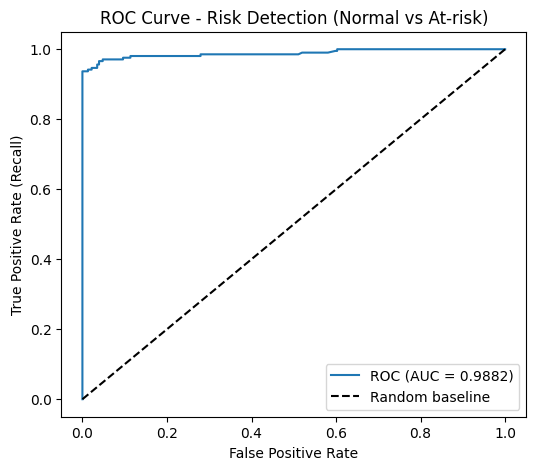

AUC-ROC: 0.9882


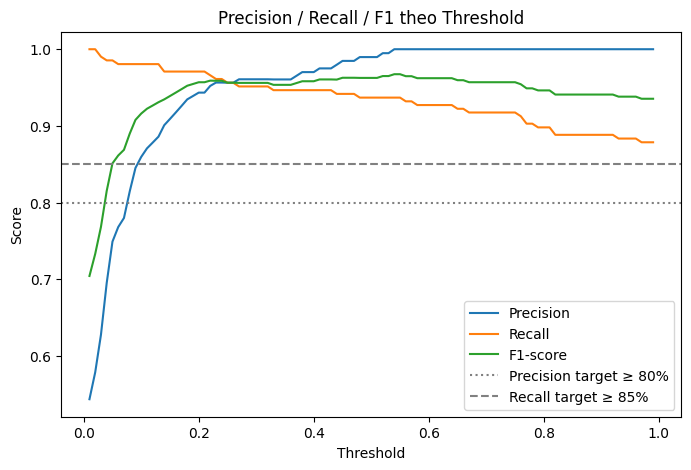


[Best F1] threshold=0.54 -> P=1.0000, R=0.9369, F1=0.9674

[Thỏa ràng buộc] threshold=0.54 -> P=1.0000, R=0.9369, F1=0.9674

=== Confusion matrix với threshold = 0.54 ===
                Normal (dự đoán)  At-risk (dự đoán)
Normal (thực)                229                  0
At-risk (thực)                13                193


In [74]:

# Binary: 0 = Normal (an toàn), 1 = Warning/Fault (rủi ro)
y_test_binary = (y_test != 0).astype(int)
risk_score = probs[:, 1] + probs[:, 2]   # xác suất rủi ro tổng, đã calibrate

# ROC Curve Analysis 
fpr, tpr, thresholds_roc = roc_curve(y_test_binary, risk_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Risk Detection (Normal vs At-risk)')
plt.legend()
plt.show()
print(f"AUC-ROC: {roc_auc:.4f}")

# Quét threshold, tính Precision/Recall/F1 
thresholds = np.linspace(0.01, 0.99, 99)
records = []
for t in thresholds:
    y_pred_t = (risk_score >= t).astype(int)
    records.append((
        t,
        precision_score(y_test_binary, y_pred_t, zero_division=0),
        recall_score(y_test_binary, y_pred_t, zero_division=0),
        f1_score(y_test_binary, y_pred_t, zero_division=0)
    ))
df_thresh = pd.DataFrame(records, columns=['threshold', 'precision', 'recall', 'f1'])

# Vẽ Precision/Recall/F1 theo threshold
plt.figure(figsize=(8, 5))
plt.plot(df_thresh['threshold'], df_thresh['precision'], label='Precision')
plt.plot(df_thresh['threshold'], df_thresh['recall'], label='Recall')
plt.plot(df_thresh['threshold'], df_thresh['f1'], label='F1-score')
plt.axhline(0.80, color='gray', linestyle=':', label='Precision target ≥ 80%')
plt.axhline(0.85, color='gray', linestyle='--', label='Recall target ≥ 85%')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 theo Threshold')
plt.legend()
plt.show()

# Threshold tối ưu F1 (không ràng buộc) 
best_f1 = df_thresh.loc[df_thresh['f1'].idxmax()]
print(f"\n[Best F1] threshold={best_f1['threshold']:.2f} -> "
      f"P={best_f1['precision']:.4f}, R={best_f1['recall']:.4f}, F1={best_f1['f1']:.4f}")

# Threshold thỏa ĐỒNG THỜI Precision≥80% VÀ Recall≥85% =
valid = df_thresh[(df_thresh['precision'] >= 0.80) & (df_thresh['recall'] >= 0.85)]

if len(valid) > 0:
    chosen = valid.loc[valid['f1'].idxmax()]   # trong vùng hợp lệ, chọn F1 cao nhất
    print(f"\n[Thỏa ràng buộc] threshold={chosen['threshold']:.2f} -> "
          f"P={chosen['precision']:.4f}, R={chosen['recall']:.4f}, F1={chosen['f1']:.4f}")
else:
    print("\n[!] Không tồn tại threshold nào thỏa ĐỒNG THỜI Precision≥80% và Recall≥85%.")
    print("5 threshold gần đạt được yêu cầu nhất:")
    df_thresh['gap'] = np.maximum(0, 0.80 - df_thresh['precision']) + np.maximum(0, 0.85 - df_thresh['recall'])
    print(df_thresh.sort_values('gap')[['threshold', 'precision', 'recall', 'f1']].head(5).to_string(index=False))

# ===== 5. Áp dụng threshold cuối cùng vào bài toán thực tế =====
final_threshold = chosen['threshold'] if len(valid) > 0 else best_f1['threshold']
y_pred_final = (risk_score >= final_threshold).astype(int)
print(f"\n=== Confusion matrix với threshold = {final_threshold:.2f} ===")
print(pd.DataFrame(
    confusion_matrix(y_test_binary, y_pred_final),
    index=['Normal (thực)', 'At-risk (thực)'],
    columns=['Normal (dự đoán)', 'At-risk (dự đoán)']
))

=== TOP 10 FEATURE QUAN TRỌNG NHẤT (GINI IMPORTANCE) ===
           Feature  Gini_Importance
      CPU_Load_Pct           0.2958
           Fan_RPM           0.2592
    Fan_Temp_Ratio           0.1612
     Temperature_C           0.0915
         Voltage_V           0.0756
  CPU_Load_Pct_std           0.0172
 CPU_Load_Pct_mean           0.0101
  CPU_Load_Pct_max           0.0098
      Fan_RPM_mean           0.0094
CPU_Load_Pct_range           0.0079


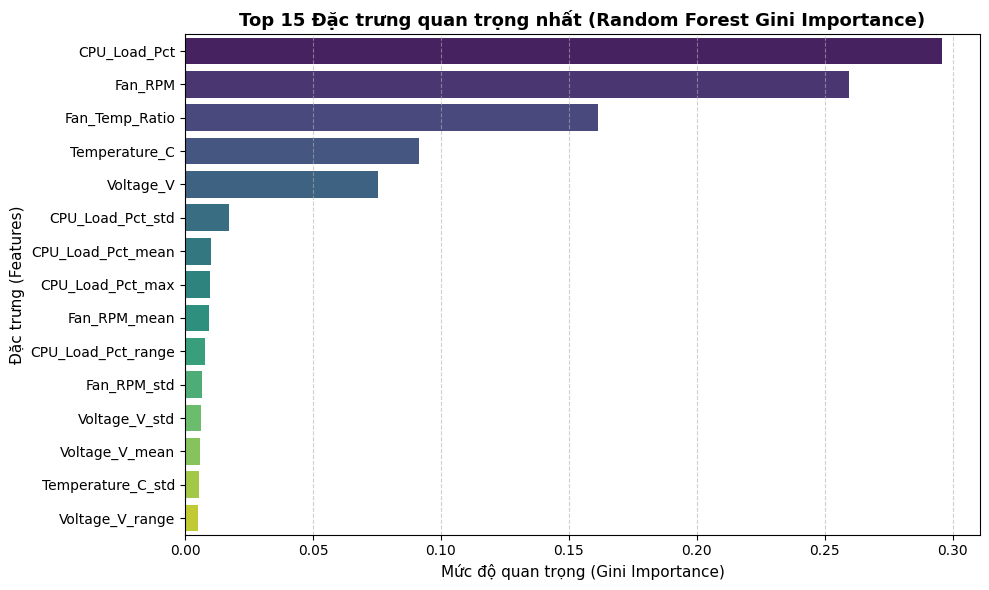

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lấy độ quan trọng từ mô hình Random Forest tốt nhất sau GridSearchCV
importances = best_rf.feature_importances_
df_gini = pd.DataFrame({
    'Feature': X.columns,
    'Gini_Importance': importances
}).sort_values('Gini_Importance', ascending=False).reset_index(drop=True)

print("=== TOP 10 FEATURE QUAN TRỌNG NHẤT (GINI IMPORTANCE) ===")
print(df_gini.head(10).round(4).to_string(index=False))

# 2. Vẽ biểu đồ Top 15 Features
plt.figure(figsize=(10, 6), dpi=100)
sns.barplot(x='Gini_Importance', y='Feature', data=df_gini.head(15), palette='viridis')
plt.title('Top 15 Đặc trưng quan trọng nhất (Random Forest Gini Importance)', fontsize=13, fontweight='bold')
plt.xlabel('Mức độ quan trọng (Gini Importance)', fontsize=11)
plt.ylabel('Đặc trưng (Features)', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()